**© Copyright AIDENTIFY. All rights reserved.**

# Part 1 | Session 4: 생성 AI와 LLM 개요

---

### 📋 학습 목표

- 🔹 생성 AI(Generative AI)의 개념과 LLM의 위치를 이해합니다
- 🔹 LLM의 발전 흐름과 주요 모델(GPT, Claude, LLaMA, Qwen 등)을 파악합니다
- 🔹 sLLM(Small LLM)의 부상 배경과 파인튜닝의 실용성을 이해합니다
- 🔹 트랜스포머(Transformer) 아키텍처의 핵심 구조를 파악합니다
- 🔹 토큰화(Tokenization)의 원리와 다양한 방식을 실습합니다
- 🔹 텍스트 생성 전략(Greedy, Beam Search, Sampling 등)을 이해합니다
- 🔹 한국어와 영어의 토큰 효율 차이를 비교합니다
- 🔹 LLM 활용 4가지 방법(프롬프트 / RAG / Agent / 파인튜닝)의 차이를 이해합니다

### 📦 필요 라이브러리

```
tiktoken, transformers, torch, matplotlib
```

### ⏱️ 예상 소요 시간: 약 90분

---

In [1]:
# 필요 라이브러리 설치 (이미 설치되어 있다면 스킵)
# !pip install tiktoken transformers torch matplotlib

import tiktoken
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 미지원 환경 대응 — 그래프 라벨은 영문 사용
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 임포트 완료!")
print(f"  - tiktoken 버전: {tiktoken.__version__}")
print(f"  - torch 버전: {torch.__version__}")
print(f"  - matplotlib 버전: {matplotlib.__version__}")
print(f"  - CUDA 사용 가능: {torch.cuda.is_available()}")

/home/ejkim/LLM_master_5parts/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ejkim/LLM_master_5parts/venv/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


✅ 라이브러리 임포트 완료!
  - tiktoken 버전: 0.12.0
  - torch 버전: 2.10.0+cu128
  - matplotlib 버전: 3.10.8
  - CUDA 사용 가능: True


---

## 🎯 생성 AI(Generative AI)란?

생성 AI는 **새로운 콘텐츠(텍스트, 이미지, 코드 등)를 생성**할 수 있는 인공지능 모델입니다.

### 생성 AI의 주요 분류

| 분류 | 설명 | 대표 모델 |
|------|------|----------|
| 텍스트 생성 | 자연어 텍스트 생성 | GPT-4, Claude, Gemini |
| 이미지 생성 | 텍스트→이미지 생성 | DALL-E 3, Midjourney, Stable Diffusion |
| 코드 생성 | 프로그래밍 코드 생성 | Codex, GitHub Copilot |
| 음성/음악 | 오디오 콘텐츠 생성 | MusicGen, Bark |
| 동영상 | 비디오 콘텐츠 생성 | Sora, Runway |

### LLM(Large Language Model)의 위치

```
인공지능 (AI)
  └── 머신러닝 (ML)
      └── 딥러닝 (DL)
          └── 생성 AI (Generative AI)
              └── LLM (Large Language Model)
                  └── sLLM (Small LLM) ← 우리가 파인튜닝할 모델!
```

### LLM의 핵심 작동 원리

LLM은 본질적으로 **"다음 토큰 예측(Next Token Prediction)"** 을 수행합니다.

```
입력: "오늘 날씨가"
  → 모델이 다음 토큰 확률 계산
  → "좋습니다" (확률 0.35), "맑습니다" (확률 0.25), ...
  → 선택된 토큰을 추가
  → "오늘 날씨가 좋습니다"
```

---

---

## 1️⃣ LLM 발전 과정

### 시대별 주요 모델 타임라인

```
2017  Transformer ("Attention Is All You Need") - Google
  │
2018  GPT-1 (117M) - OpenAI            BERT (340M) - Google
  │
2019  GPT-2 (1.5B) - OpenAI            T5 (11B) - Google
  │
2020  GPT-3 (175B) - OpenAI
  │
2021  Codex - OpenAI                   PaLM - Google
  │
2022  ChatGPT - OpenAI                 InstructGPT - OpenAI
  │    LLaMA (7~65B) - Meta
  │
2023  GPT-4 - OpenAI                   LLaMA 2 (7~70B) - Meta
  │    Claude 2 - Anthropic            Mistral 7B - Mistral AI
  │    Qwen (7~72B) - Alibaba
  │
2024  GPT-4o - OpenAI                  LLaMA 3 (8~405B) - Meta
  │    Claude 3.5 Sonnet - Anthropic   Qwen2.5 (0.5~72B) - Alibaba
  │    Gemini 1.5 - Google             DeepSeek V3/R1 - DeepSeek
  │    Phi-3 (mini~medium) - Microsoft
  │
2025  GPT-4.5 / o-series - OpenAI      LLaMA 4 - Meta
       Claude 4 - Anthropic            Qwen3 - Alibaba
       Gemini 2.5 - Google
```

### 핵심 트렌드

- 🔸 **규모의 확대**: 117M → 175B → 1T+ 파라미터
- 🔸 **오픈소스 확산**: LLaMA, Qwen, Mistral 등 오픈 가중치 공개
- 🔸 **효율성 추구**: sLLM(소형 LLM)으로 작지만 강력한 모델 개발
- 🔸 **멀티모달**: 텍스트 + 이미지 + 오디오 통합
- 🔸 **추론 능력**: CoT, 강화학습 기반 추론 모델 (o1, R1)

---

📈 LLM 발전 타임라인 시각화


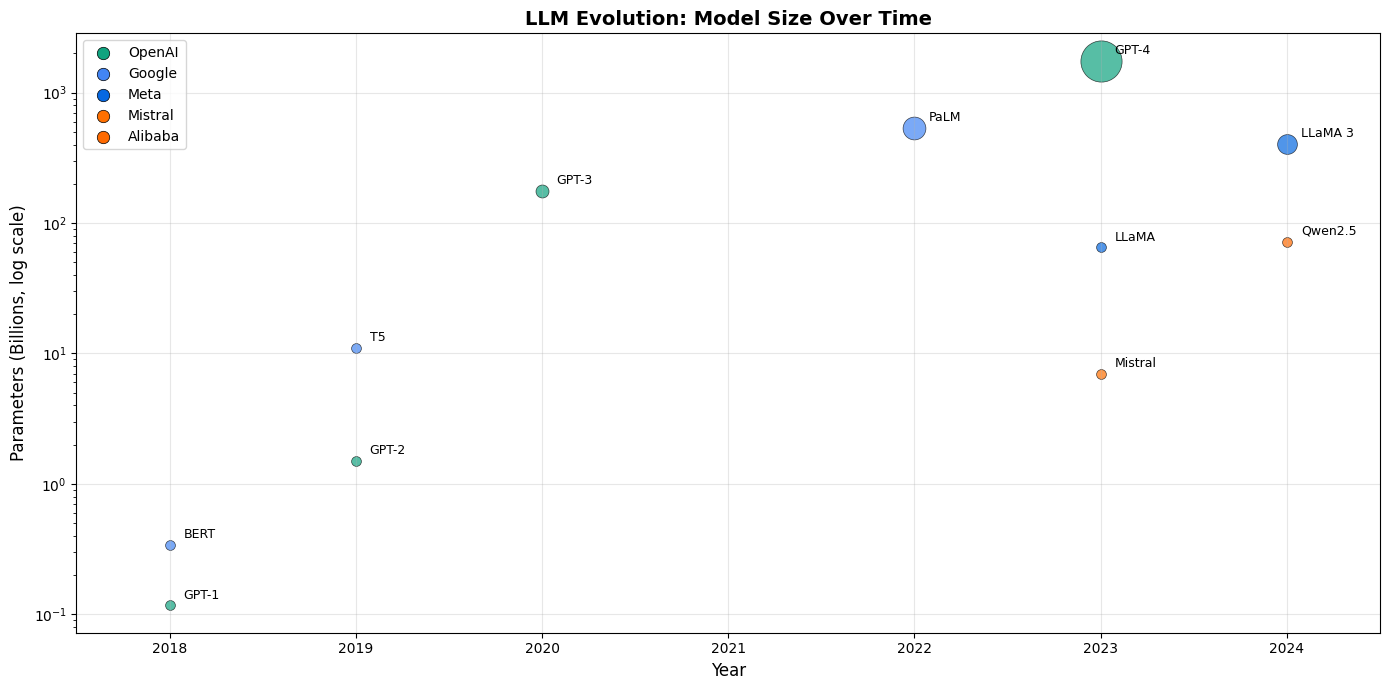


✅ 모델 크기가 지수적으로 증가하는 트렌드를 확인할 수 있습니다.
💡 최근에는 '작지만 강력한' sLLM도 함께 주목받고 있습니다 (다음 섹션).


In [2]:
# LLM 발전 타임라인 시각화
import matplotlib.pyplot as plt

print("=" * 60)
print("📈 LLM 발전 타임라인 시각화")
print("=" * 60)

# 주요 모델 데이터 (이름, 연도, 파라미터(B), 개발사)
models = [
    {"name": "GPT-1",    "year": 2018, "params": 0.117, "org": "OpenAI"},
    {"name": "BERT",     "year": 2018, "params": 0.340, "org": "Google"},
    {"name": "GPT-2",    "year": 2019, "params": 1.5,   "org": "OpenAI"},
    {"name": "T5",       "year": 2019, "params": 11,    "org": "Google"},
    {"name": "GPT-3",    "year": 2020, "params": 175,   "org": "OpenAI"},
    {"name": "PaLM",     "year": 2022, "params": 540,   "org": "Google"},
    {"name": "LLaMA",    "year": 2023, "params": 65,    "org": "Meta"},
    {"name": "GPT-4",    "year": 2023, "params": 1760,  "org": "OpenAI"},
    {"name": "Mistral",  "year": 2023, "params": 7,     "org": "Mistral"},
    {"name": "LLaMA 3",  "year": 2024, "params": 405,   "org": "Meta"},
    {"name": "Qwen2.5",  "year": 2024, "params": 72,    "org": "Alibaba"},
]

fig, ax = plt.subplots(figsize=(14, 7))

colors = {
    "OpenAI": "#10a37f",
    "Google": "#4285f4",
    "Meta":   "#0668E1",
    "Mistral":"#FF7000",
    "Alibaba":"#FF6A00",
}

for m in models:
    color = colors.get(m["org"], "gray")
    ax.scatter(m["year"], m["params"], s=max(50, m["params"] * 0.5),
               c=color, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax.annotate(m["name"], (m["year"], m["params"]),
                textcoords="offset points", xytext=(10, 5), fontsize=9)

ax.set_yscale('log')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Parameters (Billions, log scale)', fontsize=12)
ax.set_title('LLM Evolution: Model Size Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(2017.5, 2024.5)

for org, color in colors.items():
    ax.scatter([], [], c=color, s=80, label=org, edgecolors='black', linewidth=0.5)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✅ 모델 크기가 지수적으로 증가하는 트렌드를 확인할 수 있습니다.")
print("💡 최근에는 '작지만 강력한' sLLM도 함께 주목받고 있습니다 (다음 섹션).")


---

## 2️⃣ 주요 LLM 모델 비교

### 클로즈드소스 모델 (API 제공)

| 모델 | 개발사 | 특징 | 비용 (대략) |
|------|--------|------|-------------|
| GPT-4o | OpenAI | 멀티모달, 빠른 속도 | 입력 $2.5/1M, 출력 $10/1M |
| GPT-4.5 / o-series | OpenAI | 향상된 추론/창의성 | 입력 $15~$75/1M |
| Claude 3.5/4 Sonnet | Anthropic | 코딩 강점, 안전성 | 입력 $3/1M, 출력 $15/1M |
| Gemini 1.5/2.5 Pro | Google | 100만 토큰 컨텍스트 | 입력 $1.25/1M, 출력 $5/1M |

### 오픈소스 / 오픈가중치 모델

| 모델 | 개발사 | 크기 | 특징 |
|------|--------|------|------|
| LLaMA 3.1 | Meta | 8B / 70B / 405B | 가장 인기있는 오픈소스 |
| Qwen2.5 | Alibaba | 0.5B~72B | 다국어 우수, 한국어 양호 |
| Mistral / Mixtral | Mistral AI | 7B / 8x7B | MoE 아키텍처, 효율적 |
| Phi-3 / 3.5 | Microsoft | 3.8B / 7B | 작지만 강력한 성능 |
| DeepSeek R1 | DeepSeek | 7B~671B | 추론 특화, 강화학습 |
| Gemma 2 | Google | 2B / 9B / 27B | 경량 연구용 |
| EXAONE 3.5 | LG AI Research | 2.4B / 7.8B / 32B | 한국어 특화 |

> 💡 본 과정에서는 주로 **Qwen2.5 계열**(특히 1.5B-Instruct)을 실습 베이스로 사용합니다.

---

In [3]:
# 주요 오픈소스 LLM 모델 비교 표
print("=" * 88)
print("📊 주요 오픈소스 LLM 모델 비교 (2024-2025 기준)")
print("=" * 88)

models_comparison = [
    {"name": "LLaMA 3.1 8B",   "org": "Meta",      "params": "8B",   "context": "128K", "korean": "보통", "strength": "커뮤니티 생태계"},
    {"name": "Qwen2.5 7B",     "org": "Alibaba",   "params": "7B",   "context": "128K", "korean": "양호", "strength": "다국어, 코딩"},
    {"name": "Mistral 7B",     "org": "Mistral",   "params": "7B",   "context": "32K",  "korean": "보통", "strength": "효율성, 속도"},
    {"name": "Phi-3.5 Mini",   "org": "Microsoft", "params": "3.8B", "context": "128K", "korean": "보통", "strength": "크기 대비 성능"},
    {"name": "Gemma 2 9B",     "org": "Google",    "params": "9B",   "context": "8K",   "korean": "보통", "strength": "연구 친화적"},
    {"name": "EXAONE 3.5 7.8B","org": "LG AI",     "params": "7.8B", "context": "32K",  "korean": "우수", "strength": "한국어 특화"},
]

header = f"{'모델':<22} {'개발사':<12} {'파라미터':<10} {'컨텍스트':<10} {'한국어':<8} {'강점':<18}"
print(f"\n{header}")
print("-" * 88)
for m in models_comparison:
    row = f"{m['name']:<22} {m['org']:<12} {m['params']:<10} {m['context']:<10} {m['korean']:<8} {m['strength']:<18}"
    print(row)

print("\n" + "=" * 88)
print("💡 본 과정 실습 모델: Qwen2.5-1.5B-Instruct")
print("   → RTX 4060 (8GB)에서도 LoRA/QLoRA 파인튜닝이 가능한 sLLM 크기")


📊 주요 오픈소스 LLM 모델 비교 (2024-2025 기준)

모델                     개발사          파라미터       컨텍스트       한국어      강점                
----------------------------------------------------------------------------------------
LLaMA 3.1 8B           Meta         8B         128K       보통       커뮤니티 생태계          
Qwen2.5 7B             Alibaba      7B         128K       양호       다국어, 코딩           
Mistral 7B             Mistral      7B         32K        보통       효율성, 속도           
Phi-3.5 Mini           Microsoft    3.8B       128K       보통       크기 대비 성능          
Gemma 2 9B             Google       9B         8K         보통       연구 친화적            
EXAONE 3.5 7.8B        LG AI        7.8B       32K        우수       한국어 특화            

💡 본 과정 실습 모델: Qwen2.5-1.5B-Instruct
   → RTX 4060 (8GB)에서도 LoRA/QLoRA 파인튜닝이 가능한 sLLM 크기


---

## 3️⃣ sLLM(Small LLM)의 부상과 실용성

### sLLM이란?

일반적으로 **7B 이하**의 파라미터를 가진 경량 언어 모델을 sLLM이라 부릅니다. 본 강의 자료의 이름(`04_llm_overview_sllm`)에 sLLM이 들어있는 이유도 이 흐름이 LLM 활용 실무의 핵심으로 떠올랐기 때문입니다.

### sLLM이 주목받는 이유

| 장점 | 설명 |
|------|------|
| 💰 비용 절감 | 운영/추론 비용이 대형 모델의 1/10~1/100 |
| 🔒 데이터 보안 | 로컬/프라이빗 환경에서 실행 가능 |
| ⚡ 빠른 추론 | 낮은 지연시간(latency) |
| 🎯 특화 가능 | 파인튜닝으로 특정 도메인에 최적화 |
| 🖥️ 접근성 | 일반 GPU(8~24GB)에서 실행 가능 |

### 파인튜닝된 sLLM의 강점

```
범용 대형 모델 (GPT-4 등, 1T+ 파라미터)
  → 모든 분야에서 80~90점

파인튜닝된 sLLM (Qwen2.5-1.5B + 도메인 데이터)
  → 특정 분야에서 85~95점 (대형 모델과 비슷하거나 더 나은 성능)
  → 비용은 1/100, 속도는 10배 빠름
```

> 💡 본 과정에서 주로 사용하는 모델은 **Qwen2.5-1.5B-Instruct** 입니다. RTX 4060(8GB)에서도 LoRA/QLoRA 파인튜닝이 가능한 크기입니다.

---

📊 sLLM vs 대형 모델: 비용-성능 트레이드오프


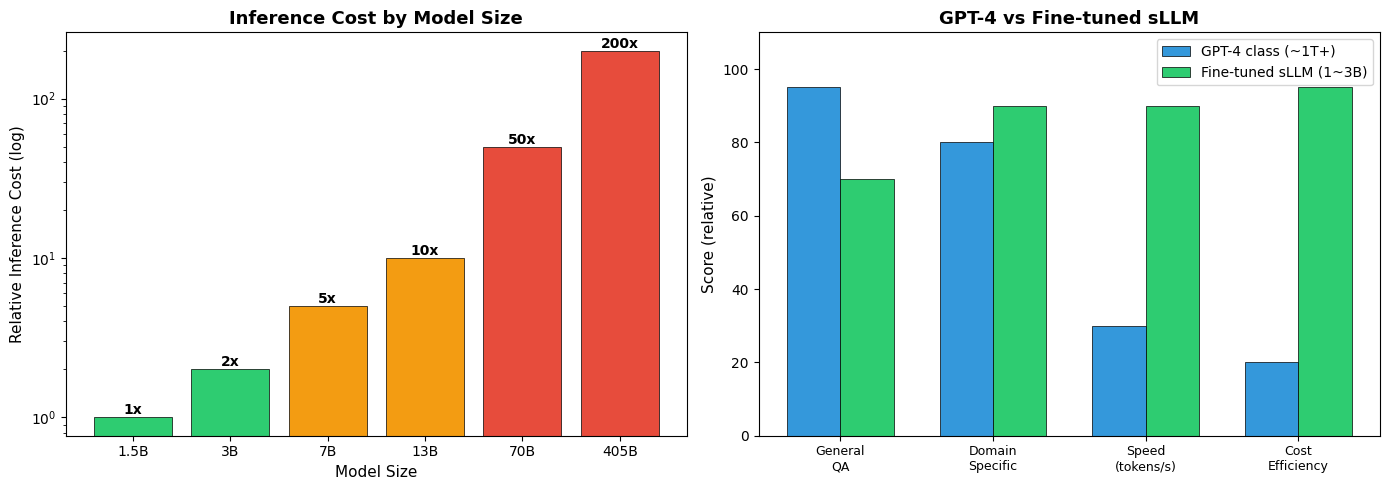


✅ 파인튜닝된 sLLM은 도메인 특화 작업에서 대형 모델을 능가할 수 있습니다.
💡 비용 효율과 속도에서는 압도적 우위 — 이것이 본 과정에서 파인튜닝을 배우는 이유입니다.


In [4]:
# sLLM vs 대형 모델 비교 시각화
import matplotlib.pyplot as plt

print("=" * 60)
print("📊 sLLM vs 대형 모델: 비용-성능 트레이드오프")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 모델 크기별 추론 비용 (상대값)
ax1 = axes[0]
model_sizes = ['1.5B', '3B', '7B', '13B', '70B', '405B']
costs_relative = [1, 2, 5, 10, 50, 200]
colors_bar = ['#2ecc71', '#2ecc71', '#f39c12', '#f39c12', '#e74c3c', '#e74c3c']

bars = ax1.bar(model_sizes, costs_relative, color=colors_bar, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Model Size', fontsize=11)
ax1.set_ylabel('Relative Inference Cost (log)', fontsize=11)
ax1.set_title('Inference Cost by Model Size', fontsize=13, fontweight='bold')
ax1.set_yscale('log')

for bar, cost in zip(bars, costs_relative):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{cost}x', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 오른쪽: 도메인 특화 성능 비교
ax2 = axes[1]
categories = ['General\nQA', 'Domain\nSpecific', 'Speed\n(tokens/s)', 'Cost\nEfficiency']
gpt4_scores = [95, 80, 30, 20]
finetuned_sllm = [70, 90, 90, 95]

x = range(len(categories))
width = 0.35
ax2.bar([i - width/2 for i in x], gpt4_scores, width, label='GPT-4 class (~1T+)',
        color='#3498db', edgecolor='black', linewidth=0.5)
ax2.bar([i + width/2 for i in x], finetuned_sllm, width, label='Fine-tuned sLLM (1~3B)',
        color='#2ecc71', edgecolor='black', linewidth=0.5)
ax2.set_ylabel('Score (relative)', fontsize=11)
ax2.set_title('GPT-4 vs Fine-tuned sLLM', fontsize=13, fontweight='bold')
ax2.set_xticks(list(x))
ax2.set_xticklabels(categories, fontsize=9)
ax2.legend(fontsize=10)
ax2.set_ylim(0, 110)

plt.tight_layout()
plt.show()

print("\n✅ 파인튜닝된 sLLM은 도메인 특화 작업에서 대형 모델을 능가할 수 있습니다.")
print("💡 비용 효율과 속도에서는 압도적 우위 — 이것이 본 과정에서 파인튜닝을 배우는 이유입니다.")


---

## 4️⃣ 트랜스포머(Transformer) 구조 이해

2017년 Google의 "Attention Is All You Need" 논문에서 제안된 트랜스포머는 현대 LLM의 기반입니다.

### 트랜스포머의 핵심 구성요소

```
┌─────────────────────────────────────────────┐
│              Transformer 구조                 │
├─────────────────────────────────────────────┤
│                                             │
│  ┌─────────────┐     ┌─────────────┐       │
│  │  Encoder     │     │  Decoder     │      │
│  │  (인코더)     │     │  (디코더)     │      │
│  │             │     │             │       │
│  │ Self-       │     │ Masked      │       │
│  │ Attention   │────▶│ Self-       │       │
│  │             │     │ Attention   │       │
│  │ Feed        │     │             │       │
│  │ Forward     │     │ Cross-      │       │
│  │             │     │ Attention   │       │
│  │             │     │             │       │
│  │             │     │ Feed        │       │
│  │             │     │ Forward     │       │
│  └─────────────┘     └─────────────┘       │
│                                             │
│  입력 임베딩 + 위치 인코딩 (Positional Encoding) │
└─────────────────────────────────────────────┘
```

### 모델 유형별 분류

| 유형 | 구조 | 대표 모델 | 주요 용도 |
|------|------|----------|----------|
| Encoder-only | 인코더만 사용 | BERT, RoBERTa | 분류, NER, 유사도 |
| Decoder-only | 디코더만 사용 | GPT, LLaMA, Qwen | 텍스트 생성 |
| Encoder-Decoder | 둘 다 사용 | T5, BART | 번역, 요약 |

### Self-Attention (자기 주의 메커니즘)

Self-Attention은 입력 시퀀스의 각 토큰이 **다른 모든 토큰과의 관계**를 계산합니다.

```
Attention(Q, K, V) = softmax(QK^T / √d_k) × V

Q (Query)  : 현재 토큰이 "무엇을 찾고 있는지"
K (Key)    : 각 토큰이 "어떤 정보를 제공하는지"
V (Value)  : 각 토큰의 "실제 정보"
```

---

In [5]:
# Self-Attention 직관적 이해를 위한 간단한 예시
import torch
import torch.nn.functional as F

print("=" * 60)
print("🔍 Self-Attention 간단 시뮬레이션")
print("=" * 60)

# 3개 토큰, 각 4차원 임베딩으로 가정
tokens = ["나는", "학생", "입니다"]
# 임의의 임베딩 벡터 (실제로는 학습된 값)
embeddings = torch.randn(3, 4)

print(f"\n📌 입력 토큰: {tokens}")
print(f"📌 임베딩 shape: {embeddings.shape} (3개 토큰 × 4차원)")

# Q, K, V 생성 (간단히 같은 임베딩 사용)
Q = embeddings
K = embeddings
V = embeddings

# Attention Score 계산
d_k = Q.shape[-1]
scores = torch.matmul(Q, K.T) / (d_k ** 0.5)
attention_weights = F.softmax(scores, dim=-1)

print(f"\n📊 Attention Weights (각 토큰이 다른 토큰에 주는 관심도):")
for i, token in enumerate(tokens):
    weights_str = ", ".join([f"{tokens[j]}: {attention_weights[i][j]:.3f}" for j in range(len(tokens))])
    print(f"  '{token}' → [{weights_str}]")

# 가중 합 계산
output = torch.matmul(attention_weights, V)
print(f"\n📌 출력 shape: {output.shape}")
print("✅ 각 토큰이 다른 토큰의 정보를 가중 합산하여 새로운 표현을 만들었습니다!")

🔍 Self-Attention 간단 시뮬레이션

📌 입력 토큰: ['나는', '학생', '입니다']
📌 임베딩 shape: torch.Size([3, 4]) (3개 토큰 × 4차원)

📊 Attention Weights (각 토큰이 다른 토큰에 주는 관심도):
  '나는' → [나는: 0.776, 학생: 0.129, 입니다: 0.095]
  '학생' → [나는: 0.184, 학생: 0.581, 입니다: 0.235]
  '입니다' → [나는: 0.175, 학생: 0.302, 입니다: 0.522]

📌 출력 shape: torch.Size([3, 4])
✅ 각 토큰이 다른 토큰의 정보를 가중 합산하여 새로운 표현을 만들었습니다!


---

## 5️⃣ 토큰화(Tokenization) 실습 - tiktoken으로 GPT 토큰화 체험

### 토큰화란?

토큰화는 텍스트를 모델이 이해할 수 있는 **숫자 단위(토큰)**로 변환하는 과정입니다.

```
"Hello World" → [15339, 2159] → 모델 입력
"안녕하세요"    → [31585, 233, 42468, 98, 46695, 244] → 모델 입력
```

### 왜 토큰화가 중요한가?

- 🔸 모델의 **입력 길이 제한** (예: 4096 토큰)에 직접 영향
- 🔸 **API 비용**이 토큰 수 기준으로 부과
- 🔸 한국어는 영어보다 더 많은 토큰을 사용 → **비용/효율 차이**

---

In [6]:
# tiktoken으로 GPT 모델의 토큰화 체험
import tiktoken

print("=" * 60)
print("🔤 tiktoken을 이용한 GPT 토큰화 실습")
print("=" * 60)

# GPT-4에서 사용하는 인코딩
enc = tiktoken.encoding_for_model("gpt-4")
print(f"\n📌 사용 인코딩: {enc.name}")

# 다양한 텍스트로 토큰화 실험
texts = [
    "Hello, World!",
    "안녕하세요, 세계!",
    "I love artificial intelligence.",
    "나는 인공지능을 좋아합니다.",
    "Fine-tuning is the process of adapting a pre-trained model.",
    "파인튜닝은 사전 학습된 모델을 적응시키는 과정입니다.",
]

print("\n" + "-" * 60)
for text in texts:
    tokens = enc.encode(text)
    print(f"\n📝 원문: \"{text}\"")
    print(f"   토큰 ID: {tokens}")
    print(f"   토큰 수: {len(tokens)}")
    
    # 각 토큰을 디코딩하여 확인
    decoded_tokens = [enc.decode([t]) for t in tokens]
    print(f"   토큰 분해: {decoded_tokens}")

print("\n" + "=" * 60)
print("✅ 한국어가 영어보다 더 많은 토큰을 사용하는 것을 확인할 수 있습니다!")

🔤 tiktoken을 이용한 GPT 토큰화 실습

📌 사용 인코딩: cl100k_base

------------------------------------------------------------

📝 원문: "Hello, World!"
   토큰 ID: [9906, 11, 4435, 0]
   토큰 수: 4
   토큰 분해: ['Hello', ',', ' World', '!']

📝 원문: "안녕하세요, 세계!"
   토큰 ID: [31495, 230, 75265, 243, 92245, 11, 28867, 116, 22783, 226, 0]
   토큰 수: 11
   토큰 분해: ['�', '�', '�', '�', '하세요', ',', ' �', '�', '�', '�', '!']

📝 원문: "I love artificial intelligence."
   토큰 ID: [40, 3021, 21075, 11478, 13]
   토큰 수: 5
   토큰 분해: ['I', ' love', ' artificial', ' intelligence', '.']

📝 원문: "나는 인공지능을 좋아합니다."
   토큰 ID: [61415, 16969, 59777, 79225, 22035, 67119, 18359, 66799, 233, 54059, 61938, 13]
   토큰 수: 12
   토큰 분해: ['나', '는', ' 인', '공', '지', '능', '을', ' �', '�', '아', '합니다', '.']

📝 원문: "Fine-tuning is the process of adapting a pre-trained model."
   토큰 ID: [64816, 2442, 38302, 374, 279, 1920, 315, 70817, 264, 864, 70024, 1646, 13]
   토큰 수: 13
   토큰 분해: ['Fine', '-t', 'uning', ' is', ' the', ' process', ' of', ' adapting', ' a', '

In [7]:
# 토큰 수 계산 유틸리티 함수
def count_tokens(text, model="gpt-4"):
    """텍스트의 토큰 수를 계산합니다."""
    enc = tiktoken.encoding_for_model(model)
    return len(enc.encode(text))

# 실습: 긴 텍스트의 토큰 수 확인
long_text_en = """Large Language Models (LLMs) are a type of artificial intelligence 
that can understand and generate human-like text. They are trained on vast amounts 
of text data and can perform a wide range of natural language processing tasks."""

long_text_ko = """대규모 언어 모델(LLM)은 인간과 유사한 텍스트를 이해하고 생성할 수 있는 
인공지능의 한 유형입니다. 방대한 양의 텍스트 데이터로 학습되며 다양한 자연어 처리 작업을 
수행할 수 있습니다."""

en_tokens = count_tokens(long_text_en)
ko_tokens = count_tokens(long_text_ko)

print("📊 긴 텍스트 토큰 비교")
print(f"\n🇺🇸 영어: {len(long_text_en)}자 → {en_tokens} 토큰")
print(f"🇰🇷 한국어: {len(long_text_ko)}자 → {ko_tokens} 토큰")
print(f"\n📌 비율: 한국어는 영어보다 약 {ko_tokens/en_tokens:.1f}배 더 많은 토큰 사용")
print("💡 즉, 같은 의미의 텍스트도 한국어가 API 비용이 더 높습니다!")

📊 긴 텍스트 토큰 비교

🇺🇸 영어: 231자 → 45 토큰
🇰🇷 한국어: 107자 → 86 토큰

📌 비율: 한국어는 영어보다 약 1.9배 더 많은 토큰 사용
💡 즉, 같은 의미의 텍스트도 한국어가 API 비용이 더 높습니다!


---

## 6️⃣ Transformers 토크나이저 비교 (BPE, WordPiece)

### 주요 토큰화 알고리즘

| 알고리즘 | 설명 | 사용 모델 |
|---------|------|----------|
| **BPE** (Byte Pair Encoding) | 가장 빈번한 바이트 쌍을 반복 병합 | GPT, LLaMA, Qwen |
| **WordPiece** | BPE와 유사, 가능도(likelihood) 기반 병합 | BERT, DistilBERT |
| **SentencePiece** | 언어 독립적, Unigram/BPE 지원 | T5, ALBERT, XLNet |

### BPE 작동 원리 (간략)

```
1. 초기: 모든 문자를 개별 토큰으로
   "lower" → ["l", "o", "w", "e", "r"]

2. 가장 빈번한 쌍 찾기 & 병합 반복
   ("l", "o") → "lo"  →  ["lo", "w", "e", "r"]
   ("lo", "w") → "low" →  ["low", "e", "r"]
   ("e", "r") → "er"  →  ["low", "er"]

3. 원하는 어휘 크기까지 반복
```

---

In [8]:
# HuggingFace Transformers 토크나이저 비교
from transformers import AutoTokenizer

print("=" * 60)
print("🔍 다양한 토크나이저 비교 실습")
print("=" * 60)

# 비교할 토크나이저들
tokenizer_names = {
    "GPT-2 (BPE)": "gpt2",
    "BERT (WordPiece)": "bert-base-uncased",
    "BERT 다국어 (WordPiece)": "bert-base-multilingual-cased",
}

test_texts = [
    "Hello, how are you?",
    "안녕하세요, 반갑습니다.",
    "Transformers are amazing for NLP!",
    "트랜스포머는 자연어 처리에 놀라운 성능을 보여줍니다.",
]

for name, model_name in tokenizer_names.items():
    print(f"\n{'=' * 60}")
    print(f"📦 토크나이저: {name} ({model_name})")
    print(f"{'=' * 60}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    print(f"   어휘 크기: {tokenizer.vocab_size:,}")

    for text in test_texts:
        tokens = tokenizer.tokenize(text)
        ids = tokenizer.encode(text, add_special_tokens=False)
        print(f"\n   📝 \"{text}\"")
        print(f"      토큰: {tokens}")
        print(f"      토큰 수: {len(tokens)}")

print("\n" + "=" * 60)
print("✅ 토크나이저마다 같은 텍스트를 다르게 분할하는 것을 확인하세요!")
print("💡 한국어 처리에는 다국어 토크나이저가 더 효율적입니다.")


🔍 다양한 토크나이저 비교 실습

📦 토크나이저: GPT-2 (BPE) (gpt2)
   어휘 크기: 50,257

   📝 "Hello, how are you?"
      토큰: ['Hello', ',', 'Ġhow', 'Ġare', 'Ġyou', '?']
      토큰 수: 6

   📝 "안녕하세요, 반갑습니다."
      토큰: ['ì', 'ķ', 'Ī', 'ë', 'ħ', 'ķ', 'íķ', 'ĺ', 'ì', 'Ħ', '¸', 'ì', 'ļ', 'Ķ', ',', 'Ġë', '°', 'ĺ', 'ê', '°', 'ĳ', 'ì', 'Ĭ', 'µ', 'ëĭ', 'Ī', 'ëĭ', '¤', '.']
      토큰 수: 29

   📝 "Transformers are amazing for NLP!"
      토큰: ['Transform', 'ers', 'Ġare', 'Ġamazing', 'Ġfor', 'ĠN', 'LP', '!']
      토큰 수: 8

   📝 "트랜스포머는 자연어 처리에 놀라운 성능을 보여줍니다."
      토큰: ['í', 'Ĭ', '¸', 'ë', 'ŀ', 'ľ', 'ì', 'Ĭ', '¤', 'í', 'ı', '¬', 'ë', '¨', '¸', 'ë', 'Ĭ', 'Ķ', 'Ġì', 'ŀ', 'Ĳ', 'ì', 'Ĺ', '°', 'ì', 'ĸ', '´', 'Ġì', '²', 'ĺ', 'ë', '¦', '¬', 'ì', 'Ĺ', 'Ĳ', 'Ġë', 'Ĩ', 'Ģ', 'ë', 'Ŀ', '¼', 'ì', 'ļ', '´', 'Ġì', 'Ħ', '±', 'ë', 'Ĭ', '¥', 'ìĿ', 'Ħ', 'Ġë', '³', '´', 'ì', 'Ĺ', '¬', 'ì', '¤', 'į', 'ëĭ', 'Ī', 'ëĭ', '¤', '.']
      토큰 수: 67

📦 토크나이저: BERT (WordPiece) (bert-base-uncased)
   어휘 크기: 30,522

   📝 "Hello, how are you?"
      토큰: ['

In [9]:
# Special Tokens 이해하기
print("=" * 60)
print("🏷️ Special Tokens (특수 토큰) 이해하기")
print("=" * 60)

# BERT 토크나이저의 특수 토큰
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
text = "Hello world"
encoded = bert_tokenizer.encode(text)  # 특수 토큰 포함
tokens_with_special = bert_tokenizer.convert_ids_to_tokens(encoded)

print(f"\n📌 BERT 특수 토큰:")
print(f"   [CLS] ID: {bert_tokenizer.cls_token_id} → 문장 시작")
print(f"   [SEP] ID: {bert_tokenizer.sep_token_id} → 문장 구분/끝")
print(f"   [PAD] ID: {bert_tokenizer.pad_token_id} → 패딩")
print(f"   [UNK] ID: {bert_tokenizer.unk_token_id} → 미등록 토큰")
print(f"   [MASK] ID: {bert_tokenizer.mask_token_id} → 마스킹")
print(f"\n   입력: \"{text}\"")
print(f"   인코딩 (특수 토큰 포함): {tokens_with_special}")
print(f"   토큰 ID: {encoded}")

# GPT-2 토크나이저의 특수 토큰
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")
print(f"\n📌 GPT-2 특수 토큰:")
print(f"   EOS (End of Sequence): '{gpt2_tokenizer.eos_token}' (ID: {gpt2_tokenizer.eos_token_id})")
print(f"   BOS (Begin of Sequence): '{gpt2_tokenizer.bos_token}' (ID: {gpt2_tokenizer.bos_token_id})")

print("\n✅ 특수 토큰은 모델이 문장의 구조를 이해하는 데 중요한 역할을 합니다!")

🏷️ Special Tokens (특수 토큰) 이해하기

📌 BERT 특수 토큰:
   [CLS] ID: 101 → 문장 시작
   [SEP] ID: 102 → 문장 구분/끝
   [PAD] ID: 0 → 패딩
   [UNK] ID: 100 → 미등록 토큰
   [MASK] ID: 103 → 마스킹

   입력: "Hello world"
   인코딩 (특수 토큰 포함): ['[CLS]', 'hello', 'world', '[SEP]']
   토큰 ID: [101, 7592, 2088, 102]

📌 GPT-2 특수 토큰:
   EOS (End of Sequence): '<|endoftext|>' (ID: 50256)
   BOS (Begin of Sequence): '<|endoftext|>' (ID: 50256)

✅ 특수 토큰은 모델이 문장의 구조를 이해하는 데 중요한 역할을 합니다!


---

## 7️⃣ 텍스트 생성 전략 (Decoding Strategies)

LLM은 다음 토큰의 **확률 분포**를 출력합니다. 이 확률에서 어떻게 토큰을 선택하느냐에 따라 생성 결과가 달라집니다.

### 토큰 생성 과정

```
입력: "나는"
   ↓ 모델이 다음 토큰의 확률 분포 출력
   학생(0.35)  선생(0.20)  사람(0.15)  매우(0.10)  ...
   ↓ 여기서 어떤 토큰을 고를 것인가? = 생성 전략!
```

### 주요 생성 전략 비교

| 전략 | 설명 | 특징 | 용도 | ChatGPT/Claude |
|------|------|------|------|----------------|
| **Greedy** | 매번 확률 1위만 선택 | 결정적, 반복 발생 가능 | 번역, 코드 생성 | ✗ |
| **Beam Search** | 상위 k개 경로를 끝까지 동시 탐색 | 전체 확률 최적화, 느림 | 번역, 음성인식 | ✗ |
| **Top-k Sampling** | 상위 k개 토큰 중 랜덤 선택 | k 고정이라 유연성 부족 | 창작 | △ |
| **Top-p (Nucleus)** | 누적 확률 p%까지의 토큰 중 랜덤 선택 | 동적 후보 수, 가장 많이 사용 | 범용 | ✅ 주로 사용 |
| **Temperature** | 확률 분포의 날카로움 조절 | 다른 전략과 함께 사용 | 전략이 아닌 파라미터 | ✅ 함께 사용 |

### 각 전략의 동작 예시

다음 토큰 확률: 학생(0.35) 선생(0.20) 사람(0.15) 매우(0.10) 정말(0.08) ...

```
Greedy:       "학생" 선택 (1위니까, 항상 같은 결과)

Beam Search:  "학생", "선생", "사람" 3개 경로를 끝까지 추적
              → 최종 문장 확률이 가장 높은 경로 선택

Top-k (k=3):  상위 3개 [학생, 선생, 사람] 중 랜덤 선택
              → 확률 분포: 학생(50%) 선생(29%) 사람(21%)

Top-p (p=0.7): 누적 확률 70%까지 포함
              → 학생(0.35) + 선생(0.20) + 사람(0.15) = 0.70 → 이 3개 중 랜덤
              → 확률 분포에 따라 후보 수가 동적으로 변함!
```

### Top-k vs Top-p 핵심 차이

```
상황 1: 확률이 한 토큰에 집중 ("1+1=")
  "2"(0.95)  "3"(0.02)  "4"(0.01) ...
  Top-k(k=10): 불필요한 9개도 후보에 포함 → 오답 가능!
  Top-p(p=0.95): "2" 하나만 선택 → 정확!

상황 2: 확률이 고르게 분산 ("오늘 저녁은")
  "치킨"(0.12) "피자"(0.11) "파스타"(0.10) "국밥"(0.09) ...
  Top-k(k=3): 3개만 후보 → 다양성 부족
  Top-p(p=0.7): 7~8개까지 후보 → 다양한 선택 가능!
```

→ **Top-p가 상황에 따라 후보 수를 자동 조절**하기 때문에 ChatGPT/Claude가 이 방식을 사용합니다.

### Temperature의 효과

Temperature는 전략이 아니라 **확률 분포를 조절하는 파라미터**입니다.

```
원래 확률:         학생(0.35)  선생(0.20)  사람(0.15)  기타(0.30)

Temperature=0.1:  학생(0.92)  선생(0.05)  사람(0.02)  기타(0.01)
                  → 1위가 거의 확정 (Greedy와 비슷)

Temperature=1.0:  학생(0.35)  선생(0.20)  사람(0.15)  기타(0.30)
                  → 원래 분포 그대로

Temperature=2.0:  학생(0.28)  선생(0.24)  사람(0.22)  기타(0.26)
                  → 거의 균등 → 랜덤에 가까움
```

| Temperature | 효과 | 비유 |
|------------|------|------|
| 0.1 | 거의 확정적 | 교과서 답안 |
| 0.7 | 적당한 다양성 (기본 권장값) | 자연스러운 대화 |
| 1.0 | 원래 확률 분포 그대로 | 자유로운 창작 |
| 1.5+ | 매우 랜덤, 비문 가능 | 횡설수설 |

---


In [10]:
# GPT-2 모델로 생성 전략 비교 실습
# (GPT-2는 작은 모델이라 CPU에서도 실행 가능)
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

print("=" * 60)
print("🎲 텍스트 생성 전략 비교 실습 (GPT-2)")
print("=" * 60)
print("\n⏳ GPT-2 모델 로딩 중... (최초 실행 시 다운로드 필요)")

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

# pad_token 설정
tokenizer.pad_token = tokenizer.eos_token

print("✅ 모델 로딩 완료!")
print(f"   모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

🎲 텍스트 생성 전략 비교 실습 (GPT-2)

⏳ GPT-2 모델 로딩 중... (최초 실행 시 다운로드 필요)
✅ 모델 로딩 완료!
   모델 파라미터 수: 124,439,808


In [11]:
# 다양한 생성 전략으로 텍스트 생성
prompt = "The future of artificial intelligence is"
input_ids = tokenizer.encode(prompt, return_tensors="pt")
attention_mask = torch.ones_like(input_ids)

print(f"📝 프롬프트: \"{prompt}\"\n")
print("=" * 60)

# 공통 인자 (경고 방지)
gen_kwargs = dict(attention_mask=attention_mask, pad_token_id=tokenizer.eos_token_id)

# 1. Greedy Decoding
print("\n1️⃣ Greedy Decoding (항상 가장 높은 확률 선택):")
with torch.no_grad():
    output = model.generate(
        input_ids, 
        max_new_tokens=50, 
        do_sample=False,  # Greedy
        **gen_kwargs,
    )
print(f"   → {tokenizer.decode(output[0], skip_special_tokens=True)}")

# 2. Beam Search
print("\n2️⃣ Beam Search (num_beams=5):")
with torch.no_grad():
    output = model.generate(
        input_ids, 
        max_new_tokens=50, 
        num_beams=5,
        do_sample=False,
        no_repeat_ngram_size=2,  # 반복 방지
        **gen_kwargs,
    )
print(f"   → {tokenizer.decode(output[0], skip_special_tokens=True)}")

# 3. Random Sampling
print("\n3️⃣ Random Sampling (temperature=1.0):")
with torch.no_grad():
    output = model.generate(
        input_ids, 
        max_new_tokens=50, 
        do_sample=True,
        temperature=1.0,
        **gen_kwargs,
    )
print(f"   → {tokenizer.decode(output[0], skip_special_tokens=True)}")

# 4. Top-k Sampling
print("\n4️⃣ Top-k Sampling (k=50):")
with torch.no_grad():
    output = model.generate(
        input_ids, 
        max_new_tokens=50, 
        do_sample=True,
        top_k=50,
        **gen_kwargs,
    )
print(f"   → {tokenizer.decode(output[0], skip_special_tokens=True)}")

# 5. Top-p (Nucleus) Sampling
print("\n5️⃣ Top-p (Nucleus) Sampling (p=0.92):")
with torch.no_grad():
    output = model.generate(
        input_ids, 
        max_new_tokens=50, 
        do_sample=True,
        top_p=0.92,
        **gen_kwargs,
    )
print(f"   → {tokenizer.decode(output[0], skip_special_tokens=True)}")

print("\n" + "=" * 60)
print("✅ 같은 프롬프트에서도 전략에 따라 생성 결과가 달라집니다!")


📝 프롬프트: "The future of artificial intelligence is"


1️⃣ Greedy Decoding (항상 가장 높은 확률 선택):
   → The future of artificial intelligence is uncertain.

"We're not sure what the future will look like," said Dr. Michael S. Schoenfeld, a professor of computer science at the University of California, Berkeley. "But we're not sure what the future will look

2️⃣ Beam Search (num_beams=5):
   → The future of artificial intelligence is in the hands of the next generation of scientists and engineers.

"It's a very exciting time to be a part of it," he said. "I think it's going to take a long time for it to become a reality."


3️⃣ Random Sampling (temperature=1.0):
   → The future of artificial intelligence is in the hands of future generations. Some think we can achieve everything without sacrificing any human capacities. However many experts see the AI revolution as already coming, the AI revolution as an exciting new possibility.


The latest round of talks in Switzerland today focused

4️⃣ Top

In [12]:
# Temperature 효과 비교
print("=" * 60)
print("🌡️ Temperature 효과 비교")
print("=" * 60)

prompt = "Once upon a time"
input_ids = tokenizer.encode(prompt, return_tensors="pt")
attention_mask = torch.ones_like(input_ids)

temperatures = [0.1, 0.5, 0.7, 1.0, 1.5]

for temp in temperatures:
    print(f"\n🌡️ Temperature = {temp}:")
    with torch.no_grad():
        output = model.generate(
            input_ids,
            attention_mask=attention_mask,
            pad_token_id=tokenizer.eos_token_id,
            max_new_tokens=40,
            do_sample=True,
            temperature=temp,
            top_p=0.95,
        )
    generated = tokenizer.decode(output[0], skip_special_tokens=True)
    print(f"   → {generated}")

print("\n" + "=" * 60)
print("💡 낮은 Temperature → 보수적/반복적")
print("💡 높은 Temperature → 창의적/불안정")
print("💡 일반적으로 0.7~0.9가 권장됩니다.")


🌡️ Temperature 효과 비교

🌡️ Temperature = 0.1:
   → Once upon a time, the world was a place of great beauty and great danger. But now, the world is a place of great danger. And now, the world is a place of great danger. And now,

🌡️ Temperature = 0.5:
   → Once upon a time, the world was in chaos.

The world was in chaos.

The world was in chaos.

The world was in chaos.

The world was in chaos.


🌡️ Temperature = 0.7:
   → Once upon a time, the Lord had said: "I will not go back, but I will go back again." And he said: "Come, let me bring you back into your house, and I will go

🌡️ Temperature = 1.0:
   → Once upon a time, I had a great deal of success with the way I wanted it, but this year, I've seen it come crashing down. I can't help feeling that, because I'm not in any

🌡️ Temperature = 1.5:
   → Once upon a time I believed him I had been the only one to find his spirit alive."

And she did, saying to the heavens where her spirit might find the source, when when it was ready, for

💡

---

## 8️⃣ 한국어 vs 영어 토큰 효율 비교

### 왜 한국어가 더 많은 토큰을 사용하는가?

- 🔸 대부분의 LLM은 **영어 중심** 학습 데이터로 토크나이저를 구축
- 🔸 영어 단어는 통째로 하나의 토큰이 되지만, 한글은 **자모 단위**로 분해
- 🔸 결과적으로 같은 의미의 한국어 문장이 **1.5~3배** 더 많은 토큰 사용
- 🔸 이는 **API 비용 증가**, **컨텍스트 윈도우 낭비**로 이어짐

### 한국어 최적화 모델의 등장

- Qwen2.5: 중국어+다국어 최적화 → 한국어도 상대적으로 효율적
- EXAONE: LG AI Research의 한국어 특화 모델
- SOLAR: Upstage의 한국어 최적화 모델

---

In [13]:
# 한국어 vs 영어 토큰 효율 상세 비교
import tiktoken

print("=" * 60)
print("🇰🇷🇺🇸 한국어 vs 영어 토큰 효율 비교")
print("=" * 60)

enc = tiktoken.encoding_for_model("gpt-4")

# 동일한 의미의 문장 쌍
pairs = [
    ("Hello", "안녕하세요"),
    ("How are you?", "잘 지내시나요?"),
    ("I am a student.", "저는 학생입니다."),
    ("Artificial Intelligence", "인공지능"),
    ("Machine Learning", "머신러닝"),
    ("Natural Language Processing", "자연어 처리"),
    (
        "The transformer model uses self-attention mechanism to process sequences.",
        "트랜스포머 모델은 셀프 어텐션 메커니즘을 사용하여 시퀀스를 처리합니다."
    ),
    (
        "Fine-tuning allows us to adapt pre-trained models to specific tasks.",
        "파인튜닝을 통해 사전 학습된 모델을 특정 작업에 적응시킬 수 있습니다."
    ),
]

total_en = 0
total_ko = 0

print(f"\n{'영어':<50} {'토큰':>5} | {'한국어':<50} {'토큰':>5} | {'비율':>5}")
print("-" * 125)

for en, ko in pairs:
    en_tokens = len(enc.encode(en))
    ko_tokens = len(enc.encode(ko))
    ratio = ko_tokens / en_tokens if en_tokens > 0 else 0
    total_en += en_tokens
    total_ko += ko_tokens
    
    print(f"{en:<50} {en_tokens:>5} | {ko:<50} {ko_tokens:>5} | {ratio:>5.1f}x")

print("-" * 125)
print(f"{'합계':<50} {total_en:>5} | {'합계':<50} {total_ko:>5} | {total_ko/total_en:>5.1f}x")

print(f"\n📊 평균적으로 한국어는 영어의 약 {total_ko/total_en:.1f}배 토큰을 사용합니다.")
print(f"💡 API 비용으로 환산하면 한국어 처리가 약 {total_ko/total_en:.1f}배 더 비쌉니다!")

🇰🇷🇺🇸 한국어 vs 영어 토큰 효율 비교

영어                                                    토큰 | 한국어                                                   토큰 |    비율
-----------------------------------------------------------------------------------------------------------------------------
Hello                                                  1 | 안녕하세요                                                  5 |   5.0x
How are you?                                           4 | 잘 지내시나요?                                               8 |   2.0x
I am a student.                                        5 | 저는 학생입니다.                                              8 |   1.6x
Artificial Intelligence                                3 | 인공지능                                                   4 |   1.3x
Machine Learning                                       2 | 머신러닝                                                   7 |   3.5x
Natural Language Processing                            3 | 자연어 처리                                   

In [14]:
# 한글 토큰화 상세 분석: 자모 분해 확인
print("=" * 60)
print("🔬 한글 토큰화 상세 분석")
print("=" * 60)

enc = tiktoken.encoding_for_model("gpt-4")

korean_words = ["안녕하세요", "인공지능", "파인튜닝", "트랜스포머", "대규모언어모델"]

for word in korean_words:
    tokens = enc.encode(word)
    decoded_parts = []
    for t in tokens:
        decoded = enc.decode([t])
        decoded_parts.append(repr(decoded))
    
    print(f"\n📝 '{word}'")
    print(f"   토큰 수: {len(tokens)}")
    print(f"   토큰 ID: {tokens}")
    print(f"   분해: {' | '.join(decoded_parts)}")

print("\n" + "=" * 60)
print("💡 한글은 UTF-8 바이트 단위로 쪼개져서 토큰이 많아집니다.")
print("💡 한국어 특화 모델(Qwen, EXAONE 등)은 이 문제를 개선했습니다.")

🔬 한글 토큰화 상세 분석

📝 '안녕하세요'
   토큰 수: 5
   토큰 ID: [31495, 230, 75265, 243, 92245]
   분해: '�' | '�' | '�' | '�' | '하세요'

📝 '인공지능'
   토큰 수: 4
   토큰 ID: [32428, 79225, 22035, 67119]
   분해: '인' | '공' | '지' | '능'

📝 '파인튜닝'
   토큰 수: 7
   토큰 ID: [67218, 234, 32428, 26787, 250, 9019, 251]
   분해: '�' | '�' | '인' | '�' | '�' | '�' | '�'

📝 '트랜스포머'
   토큰 수: 10
   토큰 ID: [29726, 39519, 250, 25941, 169, 237, 105, 167, 101, 116]
   분해: '트' | '�' | '�' | '스' | '�' | '�' | '�' | '�' | '�' | '�'

📝 '대규모언어모델'
   토큰 수: 12
   토큰 ID: [67945, 90161, 250, 41847, 101, 28498, 116, 32179, 41847, 101, 69697, 116]
   분해: '대' | '�' | '�' | '�' | '�' | '�' | '�' | '어' | '�' | '�' | '�' | '�'

💡 한글은 UTF-8 바이트 단위로 쪼개져서 토큰이 많아집니다.
💡 한국어 특화 모델(Qwen, EXAONE 등)은 이 문제를 개선했습니다.


---

## 9️⃣ LLM 활용 4가지 방법 개요

LLM을 실제 업무에 활용하는 방법은 크게 4가지로 나눌 수 있습니다. 본 과정에서 모두 다루며, 각각의 특성과 적합한 사용 사례를 이해해두면 향후 의사결정에 도움이 됩니다.

### 4가지 방법 한눈에 보기

```
┌────────────────┬───────────────┬──────────────┬───────────────┐
│ 프롬프트 엔지니어링│ RAG           │ Agent        │ 파인튜닝       │
├────────────────┼───────────────┼──────────────┼───────────────┤
│ 지시문 최적화   │ 외부 지식 검색 │ 도구 활용     │ 모델 자체 학습  │
│ 가장 간단      │ 지식 보강      │ 자율 행동     │ 가장 심화      │
│ 모델 변경 없음 │ 모델 변경 없음 │ 모델 변경 없음 │ 모델 가중치 수정│
└────────────────┴───────────────┴──────────────┴───────────────┘
```

### 의사결정 플로우

```
LLM 활용이 필요한 작업
        │
        ▼
  ┌─ 기존 모델로 충분한가? ──── Yes ──▶ 프롬프트 엔지니어링
  │       │
  │      No
  │       ▼
  ├─ 최신/특정 지식이 필요한가? ── Yes ──▶ RAG
  │       │
  │      No
  │       ▼
  ├─ 외부 도구/시스템 연동? ──── Yes ──▶ Agent
  │       │
  │      No
  │       ▼
  └─ 도메인 특화/스타일 변경? ── Yes ──▶ 파인튜닝
```

> 💡 실무에서는 4가지 방법을 단독으로 쓰기보다 **조합**해서 사용합니다. 예: 파인튜닝된 sLLM + RAG, 또는 파인튜닝 + Agent.

---

In [15]:
# LLM 활용 4가지 방법 상세 비교
print("=" * 80)
print("📋 LLM 활용 4가지 방법 상세 비교")
print("=" * 80)

methods = [
    {
        "name": "1. 프롬프트 엔지니어링",
        "description": "모델에 주는 지시문(프롬프트)을 최적화",
        "difficulty": "⭐ (쉬움)",
        "cost": "💰 (낮음)",
        "gpu": "불필요",
        "data": "불필요",
        "time": "분 단위",
        "pros": "즉시 적용, 비용 낮음",
        "cons": "성능 한계, 복잡한 작업 어려움",
    },
    {
        "name": "2. RAG (검색 증강 생성)",
        "description": "외부 문서를 검색하여 LLM에 제공",
        "difficulty": "⭐⭐ (보통)",
        "cost": "💰💰 (중간)",
        "gpu": "임베딩용 소규모",
        "data": "문서/지식 베이스",
        "time": "일~주 단위",
        "pros": "최신 정보 반영, 환각 감소",
        "cons": "검색 품질 의존, 파이프라인 복잡",
    },
    {
        "name": "3. Agent (에이전트)",
        "description": "LLM이 도구를 사용하여 자율적 행동",
        "difficulty": "⭐⭐⭐ (높음)",
        "cost": "💰💰💰 (높음)",
        "gpu": "불필요 (API 사용)",
        "data": "도구 정의",
        "time": "주 단위",
        "pros": "복잡한 작업 자동화, 외부 시스템 연동",
        "cons": "비용 높음, 예측 어려움, 디버깅 복잡",
    },
    {
        "name": "4. 파인튜닝 (Fine-tuning)",
        "description": "모델 가중치를 직접 학습하여 수정",
        "difficulty": "⭐⭐⭐⭐ (매우 높음)",
        "cost": "💰💰 (GPU 비용)",
        "gpu": "필수 (8GB+)",
        "data": "학습 데이터셋 필요",
        "time": "일~주 단위",
        "pros": "도메인 특화, 성능 극대화, 추론 비용 절감",
        "cons": "데이터/GPU 필요, 학습 시간, 전문 지식",
    },
]

for m in methods:
    print(f"\n{'─' * 80}")
    print(f"📌 {m['name']}")
    print(f"   설명: {m['description']}")
    print(f"   난이도: {m['difficulty']}  |  비용: {m['cost']}")
    print(f"   GPU: {m['gpu']}  |  데이터: {m['data']}  |  소요시간: {m['time']}")
    print(f"   ✅ 장점: {m['pros']}")
    print(f"   ⚠️ 단점: {m['cons']}")

print(f"\n{'═' * 80}")
print("💡 본 과정에서 4가지 방법을 모두 학습하고, Part 2~3에서 파인튜닝에 집중합니다!")


📋 LLM 활용 4가지 방법 상세 비교

────────────────────────────────────────────────────────────────────────────────
📌 1. 프롬프트 엔지니어링
   설명: 모델에 주는 지시문(프롬프트)을 최적화
   난이도: ⭐ (쉬움)  |  비용: 💰 (낮음)
   GPU: 불필요  |  데이터: 불필요  |  소요시간: 분 단위
   ✅ 장점: 즉시 적용, 비용 낮음
   ⚠️ 단점: 성능 한계, 복잡한 작업 어려움

────────────────────────────────────────────────────────────────────────────────
📌 2. RAG (검색 증강 생성)
   설명: 외부 문서를 검색하여 LLM에 제공
   난이도: ⭐⭐ (보통)  |  비용: 💰💰 (중간)
   GPU: 임베딩용 소규모  |  데이터: 문서/지식 베이스  |  소요시간: 일~주 단위
   ✅ 장점: 최신 정보 반영, 환각 감소
   ⚠️ 단점: 검색 품질 의존, 파이프라인 복잡

────────────────────────────────────────────────────────────────────────────────
📌 3. Agent (에이전트)
   설명: LLM이 도구를 사용하여 자율적 행동
   난이도: ⭐⭐⭐ (높음)  |  비용: 💰💰💰 (높음)
   GPU: 불필요 (API 사용)  |  데이터: 도구 정의  |  소요시간: 주 단위
   ✅ 장점: 복잡한 작업 자동화, 외부 시스템 연동
   ⚠️ 단점: 비용 높음, 예측 어려움, 디버깅 복잡

────────────────────────────────────────────────────────────────────────────────
📌 4. 파인튜닝 (Fine-tuning)
   설명: 모델 가중치를 직접 학습하여 수정
   난이도: ⭐⭐⭐⭐ (매우 높음)  |  비용: 💰💰 (GPU 비용)
   GPU: 필수 (8G

---

## 📝 정리 및 핵심 요약

### 이번 세션에서 배운 내용

| 주제 | 핵심 내용 |
|------|----------|
| 생성 AI | 새로운 콘텐츠를 만들어내는 AI, LLM은 텍스트 생성 |
| LLM 발전 | 2017 Transformer → GPT 시리즈 → 멀티모달/추론 모델 (2025) |
| 주요 모델 | GPT-4, Claude, LLaMA, Qwen, Mistral, EXAONE 등 |
| sLLM | 7B 이하 경량 모델, 파인튜닝으로 도메인 특화 가능 |
| 트랜스포머 | Self-Attention 기반, Encoder/Decoder 구조 |
| 토큰화 | 텍스트→숫자 변환, BPE/WordPiece 등 다양한 방식 |
| 생성 전략 | Greedy, Beam Search, Top-k, Top-p, Temperature |
| 한국어 효율 | 영어 대비 1.5~3배 토큰 사용, 비용 및 컨텍스트 영향 |
| 활용 방법 | 프롬프트 → RAG → Agent → 파인튜닝 (복잡도 순) |

### 핵심 메시지

- 🔑 **"큰 모델 = 좋은 모델"이 아닙니다** — 좋은 데이터 + 좋은 학습 기법이 더 중요
- 🔑 **파인튜닝된 sLLM은 특정 도메인에서 대형 모델을 능가할 수 있습니다** — 비용은 1/100, 속도는 10배 이상
- 🔑 **4가지 방법을 적절히 조합하는 것이 실무의 핵심** — 본 과정 Part 2~3에서 파인튜닝에 집중

### 다음 세션 예고

- 🔜 **Session 5**: HuggingFace 생태계 - Transformers 라이브러리 & Hub 활용법

---

### 💡 실습 과제

1. 자신의 이름과 자기소개를 한국어/영어로 작성하고, 토큰 수를 비교해보세요.
2. GPT-2 모델로 다양한 프롬프트에 대해 생성 전략별 결과를 비교해보세요.
3. (선택) 다른 토크나이저(예: `Qwen/Qwen2.5-1.5B-Instruct`)를 로딩하여 한국어 토큰 효율을 비교해보세요.
4. (선택) 자신의 업무/관심 분야에서 LLM을 활용한다면, 4가지 방법 중 어떤 것이 적합할지 판단해보세요.

---